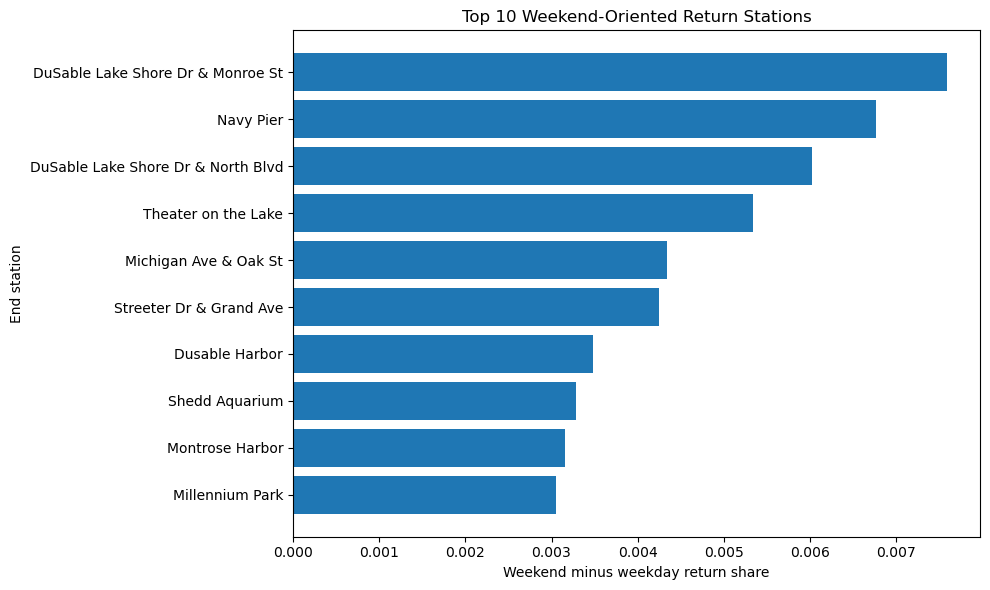

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "outputs"

station_compare = pd.read_csv(
    os.path.join(OUTPUT_DIR, "layer1_weekday_weekend_return_station_comparison.csv")
)

top_weekend = (
    station_compare
    .sort_values("weekend_minus_weekday_share", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_weekend["end_station_name"],
    top_weekend["weekend_minus_weekday_share"]
)
plt.xlabel("Weekend minus weekday return share")
plt.ylabel("End station")
plt.title("Top 10 Weekend-Oriented Return Stations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_weekend_oriented_stations.png"), dpi=300)
plt.show()

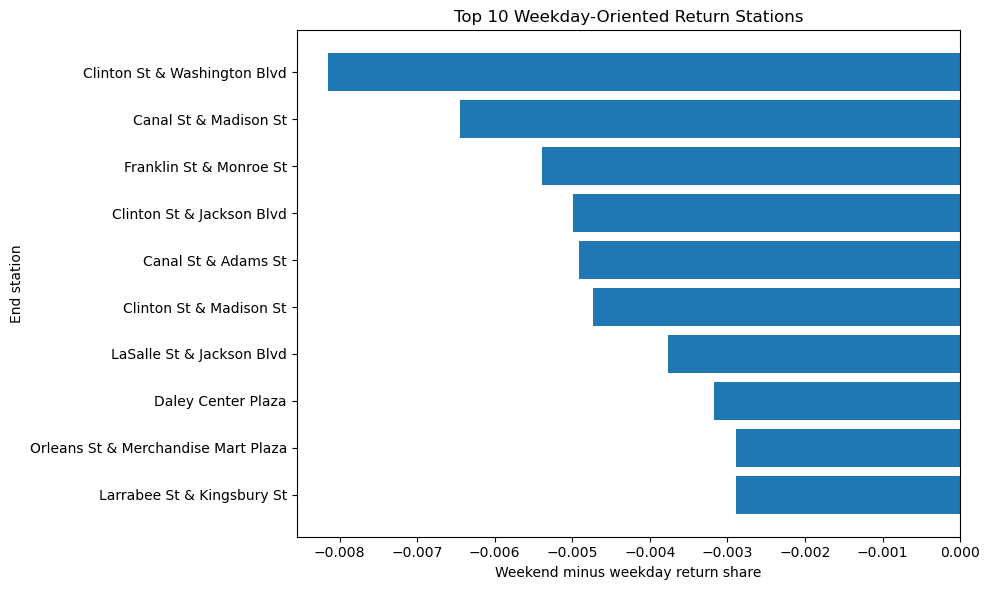

In [2]:
top_weekday = (
    station_compare
    .sort_values("weekend_minus_weekday_share", ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_weekday["end_station_name"],
    top_weekday["weekend_minus_weekday_share"]
)
plt.xlabel("Weekend minus weekday return share")
plt.ylabel("End station")
plt.title("Top 10 Weekday-Oriented Return Stations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_weekday_oriented_stations.png"), dpi=300)
plt.show()

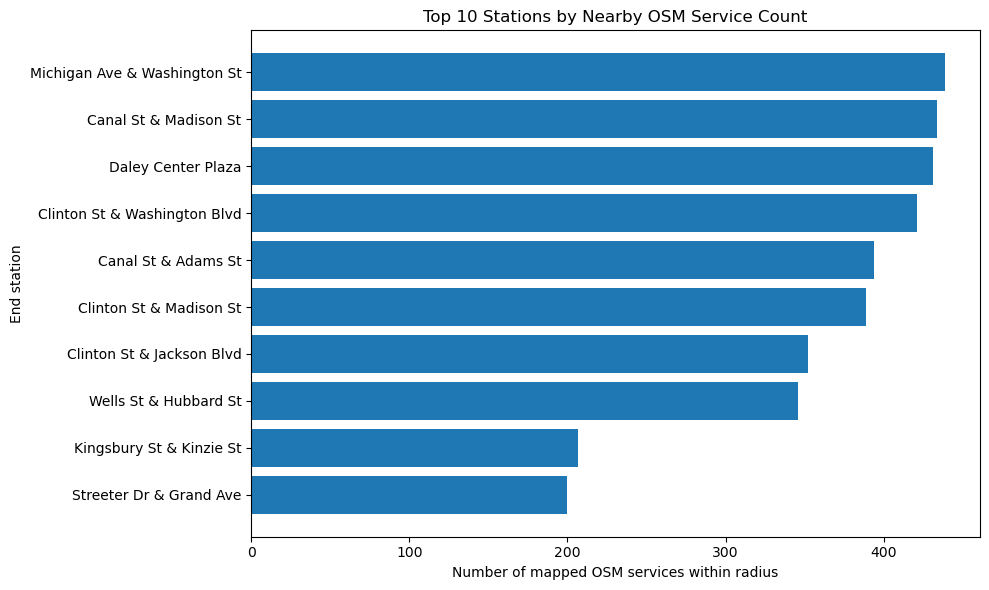

In [ ]:
service_counts = pd.read_csv(
    os.path.join(OUTPUT_DIR, "top20_end_station_osm_service_counts_250m.csv")
)

total_col = [c for c in service_counts.columns if c.startswith("total_services")][0]

top_services = service_counts.sort_values(total_col, ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_services["end_station_name"],
    top_services[total_col]
)
plt.xlabel("Number of mapped OSM services within radius")
plt.ylabel("End station")
plt.title("Top 10 Stations by Nearby OSM Service Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_station_osm_service_count.png"), dpi=300)
plt.show()

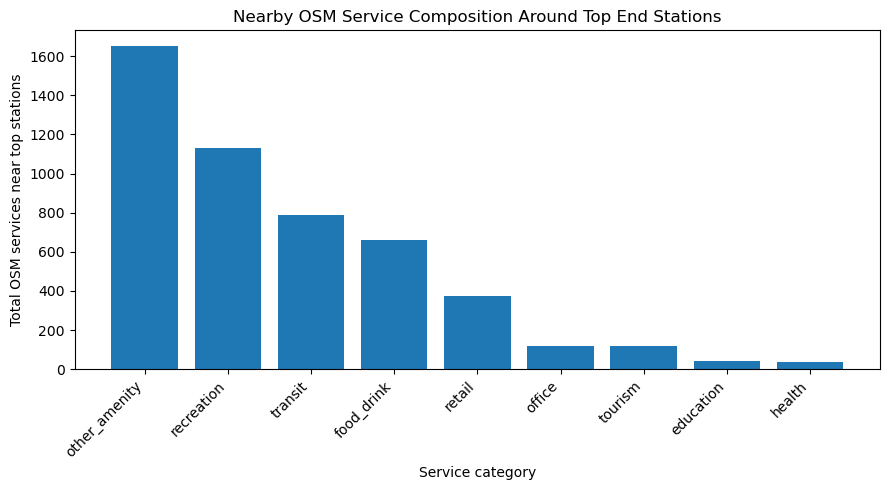

In [5]:
exclude_cols = {
    "end_station_name",
    "end_trip_count",
    "end_lat",
    "end_lng",
    total_col
}

service_cols = [
    c for c in service_counts.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(service_counts[c])
]

service_totals = service_counts[service_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(service_totals.index, service_totals.values)
plt.xlabel("Service category")
plt.ylabel("Total OSM services near top stations")
plt.title("Nearby OSM Service Composition Around Top End Stations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "osm_service_category_composition.png"), dpi=300)
plt.show()

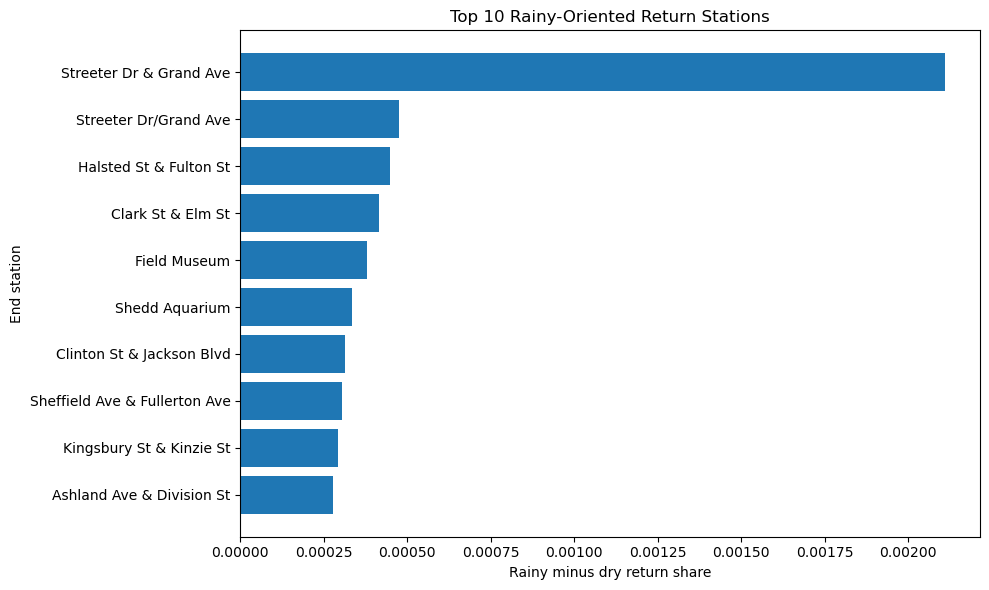

In [6]:
rain = pd.read_csv(
    os.path.join(OUTPUT_DIR, "weather_rainy_vs_dry_return_station_comparison_overall.csv")
)

top_rainy = rain.sort_values("rainy_minus_dry_share", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_rainy["end_station_name"],
    top_rainy["rainy_minus_dry_share"]
)
plt.xlabel("Rainy minus dry return share")
plt.ylabel("End station")
plt.title("Top 10 Rainy-Oriented Return Stations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_rainy_oriented_stations.png"), dpi=300)
plt.show()

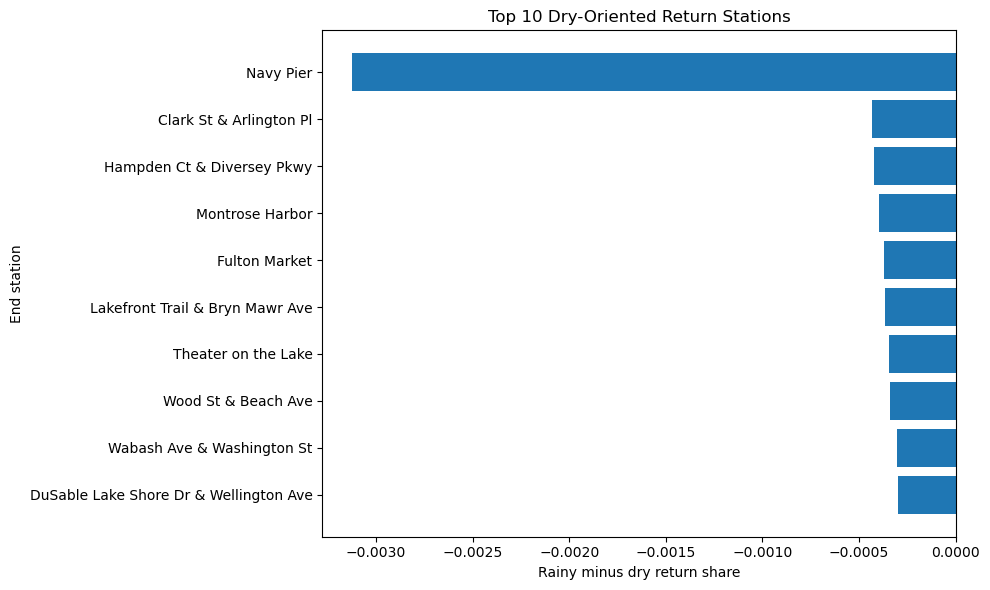

In [7]:
top_dry = rain.sort_values("rainy_minus_dry_share", ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_dry["end_station_name"],
    top_dry["rainy_minus_dry_share"]
)
plt.xlabel("Rainy minus dry return share")
plt.ylabel("End station")
plt.title("Top 10 Dry-Oriented Return Stations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_dry_oriented_stations.png"), dpi=300)
plt.show()

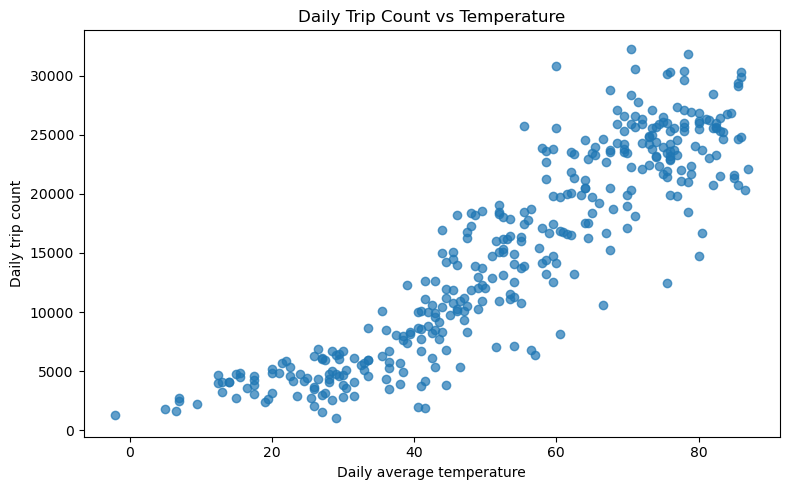

In [8]:
daily_weather = pd.read_csv("daily_trip_weather_summary.csv")

daily_weather["TAVG"] = (daily_weather["TMAX"] + daily_weather["TMIN"]) / 2

plt.figure(figsize=(8, 5))
plt.scatter(
    daily_weather["TAVG"],
    daily_weather["daily_trip_count"],
    alpha=0.7
)
plt.xlabel("Daily average temperature")
plt.ylabel("Daily trip count")
plt.title("Daily Trip Count vs Temperature")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "daily_trip_count_vs_temperature.png"), dpi=300)
plt.show()

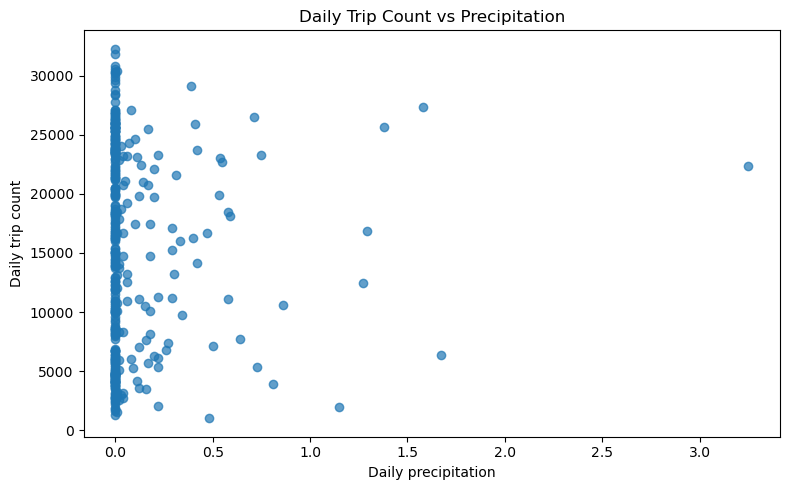

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    daily_weather["PRCP"],
    daily_weather["daily_trip_count"],
    alpha=0.7
)
plt.xlabel("Daily precipitation")
plt.ylabel("Daily trip count")
plt.title("Daily Trip Count vs Precipitation")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "daily_trip_count_vs_precipitation.png"), dpi=300)
plt.show()

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STATION_WEATHER_COUNTS_PATH = os.path.join(
    OUTPUT_DIR,
    "station_weather_return_counts.csv"
)

STATION_COORDS_PATH = os.path.join(
    OUTPUT_DIR,
    "station_coordinates_from_cleaned_divvy.csv"
)

station_weather_counts = pd.read_csv(STATION_WEATHER_COUNTS_PATH)
station_coords = pd.read_csv(STATION_COORDS_PATH)

station_weather_counts["end_station_name"] = (
    station_weather_counts["end_station_name"]
    .astype(str)
    .str.strip()
)

station_coords["end_station_name"] = (
    station_coords["end_station_name"]
    .astype(str)
    .str.strip()
)

# Merge coordinates
station_weather_geo = station_weather_counts.merge(
    station_coords,
    on="end_station_name",
    how="left"
)

station_weather_geo = station_weather_geo.dropna(
    subset=["end_lat", "end_lng"]
).copy()

# Calculate return share inside each day_type + weather condition
station_weather_geo["total_returns_in_group"] = (
    station_weather_geo
    .groupby(["condition_type", "day_type", "condition_value"])["return_count"]
    .transform("sum")
)

station_weather_geo["return_share"] = (
    station_weather_geo["return_count"] /
    station_weather_geo["total_returns_in_group"]
)

output_csv = os.path.join(
    OUTPUT_DIR,
    "station_weather_geo_with_return_share.csv"
)

station_weather_geo.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(station_weather_geo.head())
print(station_weather_geo[["condition_type", "condition_value", "day_type"]].drop_duplicates())

Saved: outputs\station_weather_geo_with_return_share.csv


,condition_type,day_type,condition_value,end_station_name,return_count,end_lat,end_lng,total_returns_in_group,return_share
0,cold,weekday,cold,2112 W Peterson Ave,41,41.991178,-87.683593,285975,0.000143
1,cold,weekday,cold,21st St & Pulaski Rd,3,41.853576,-87.724695,285975,0.000010
2,cold,weekday,cold,63rd St Beach,7,41.780911,-87.576324,285975,0.000024
3,cold,weekday,cold,900 W Harrison St,862,41.874754,-87.649807,285975,0.003014
4,cold,weekday,cold,Aberdeen St & 103rd St,2,41.707040,-87.650220,285975,0.000007


      condition_type condition_value day_type
0               cold            cold  weekday
1362            cold            mild  weekday
3211            cold            cold  weekend
4441            cold            mild  weekend
6102            rain             dry  weekday
7916            rain           rainy  weekday
9572            rain             dry  weekend
11151           rain           rainy  weekend
12675           snow         no_snow  weekday
14545           snow           snowy  weekday
15640           snow         no_snow  weekend
17311           snow           snowy  weekend


In [2]:
top_station_rows = []

for (condition_type, condition_value, day_type), group in station_weather_geo.groupby(
    ["condition_type", "condition_value", "day_type"]
):
    top_group = (
        group
        .sort_values("return_share", ascending=False)
        .head(20)
        .copy()
    )
    
    top_group["rank_in_group"] = range(1, len(top_group) + 1)
    
    top_station_rows.append(top_group)

top_weather_stations = pd.concat(top_station_rows, ignore_index=True)

top_weather_stations = top_weather_stations[[
    "condition_type",
    "condition_value",
    "day_type",
    "rank_in_group",
    "end_station_name",
    "return_count",
    "return_share",
    "total_returns_in_group",
    "end_lat",
    "end_lng"
]]

output_csv = os.path.join(
    OUTPUT_DIR,
    "top20_end_stations_by_daytype_weather.csv"
)

top_weather_stations.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(top_weather_stations.head(30))

Saved: outputs\top20_end_stations_by_daytype_weather.csv


,condition_type,condition_value,day_type,rank_in_group,end_station_name,return_count,return_share,total_returns_in_group,end_lat,end_lng
0,cold,cold,weekday,1,Clinton St & Washington Blvd,4067,0.014222,285975,41.883379,-87.641170
1,cold,cold,weekday,2,Canal St & Madison St,3877,0.013557,285975,41.882409,-87.639767
2,cold,cold,weekday,3,Kingsbury St & Kinzie St,3474,0.012148,285975,41.889173,-87.638500
3,cold,cold,weekday,4,Clinton St & Madison St,3333,0.011655,285975,41.882750,-87.641190
4,cold,cold,weekday,5,Clinton St & Jackson Blvd,2750,0.009616,285975,41.878317,-87.640981
5,cold,cold,weekday,6,Canal St & Adams St,2695,0.009424,285975,41.879255,-87.639904
6,cold,cold,weekday,7,University Ave & 57th St,2534,0.008861,285975,41.791478,-87.599861
7,cold,cold,weekday,8,State St & Chicago Ave,2208,0.007721,285975,41.896617,-87.628579
8,cold,cold,weekday,9,Clinton St & Lake St,2132,0.007455,285975,41.885637,-87.641823
9,cold,cold,weekday,10,Ellis Ave & 60th St,2077,0.007263,285975,41.785097,-87.601073


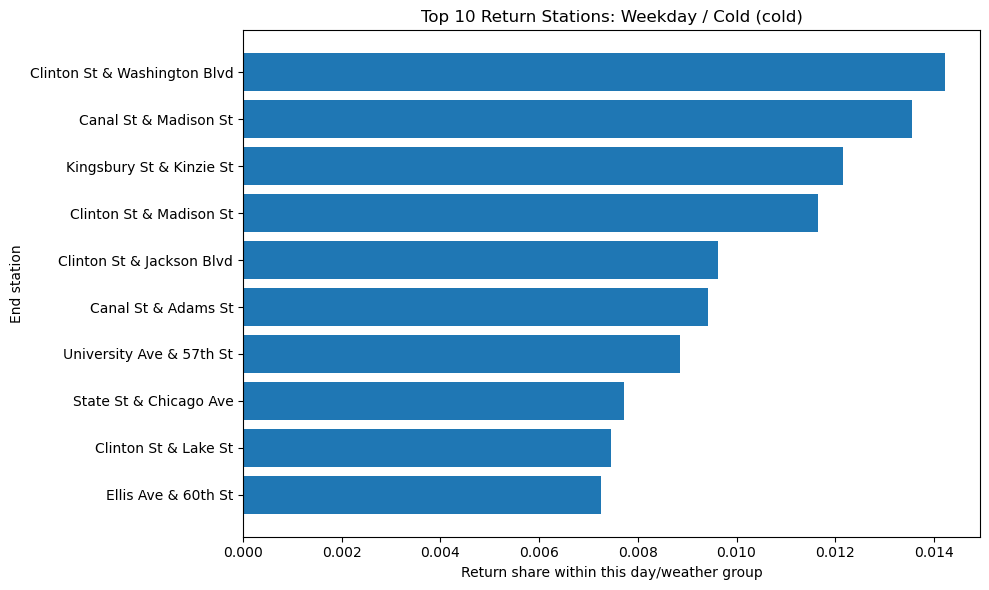

Saved: outputs\weather_station_figures\top10_weekday_cold_cold_return_stations.png


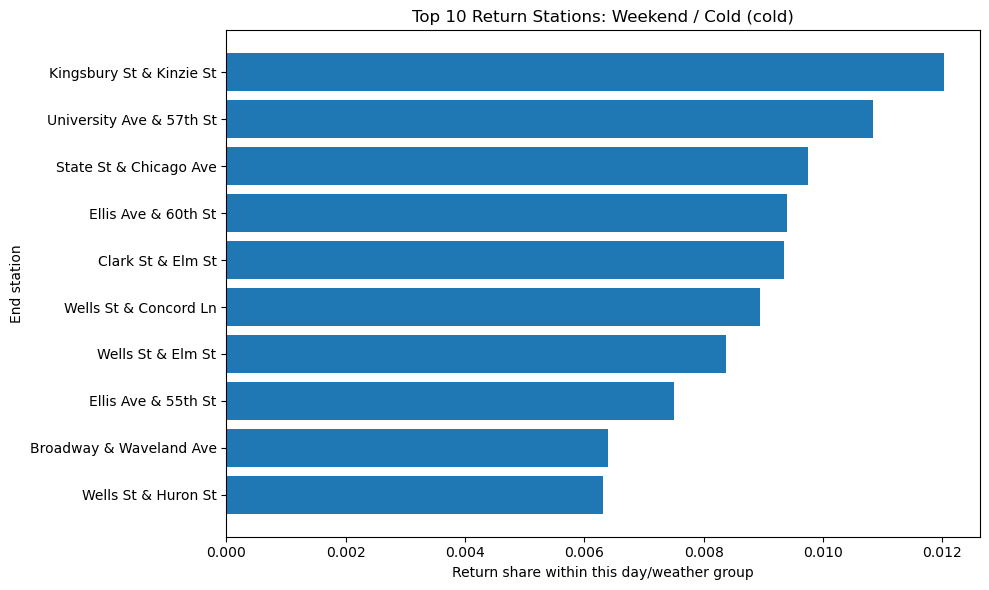

Saved: outputs\weather_station_figures\top10_weekend_cold_cold_return_stations.png


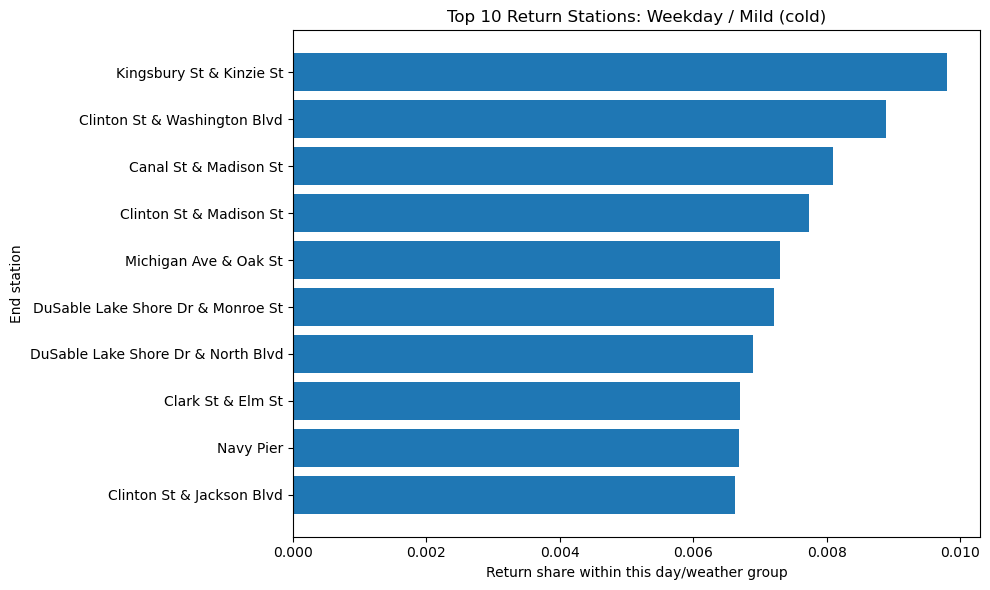

Saved: outputs\weather_station_figures\top10_weekday_cold_mild_return_stations.png


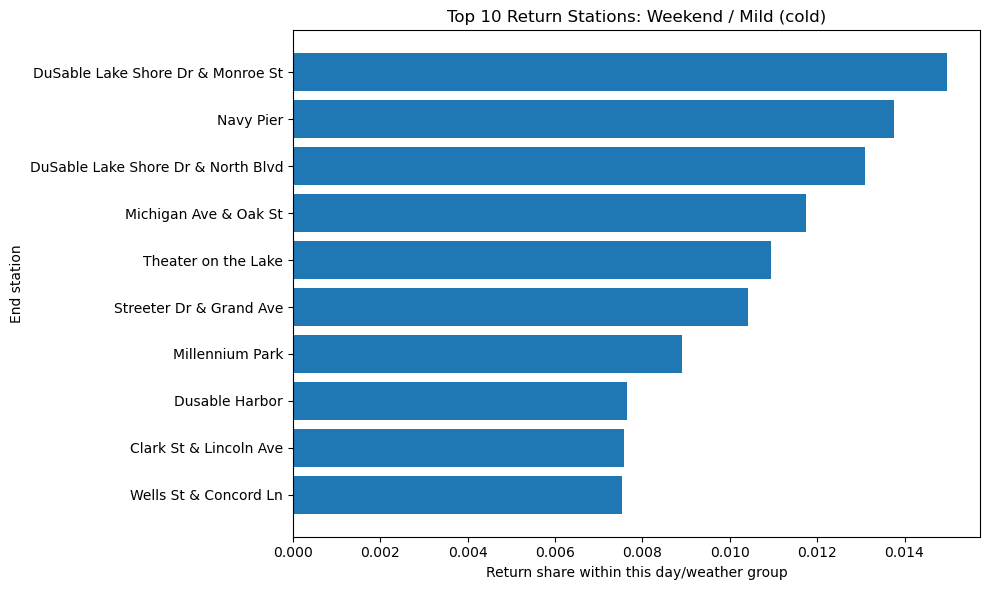

Saved: outputs\weather_station_figures\top10_weekend_cold_mild_return_stations.png


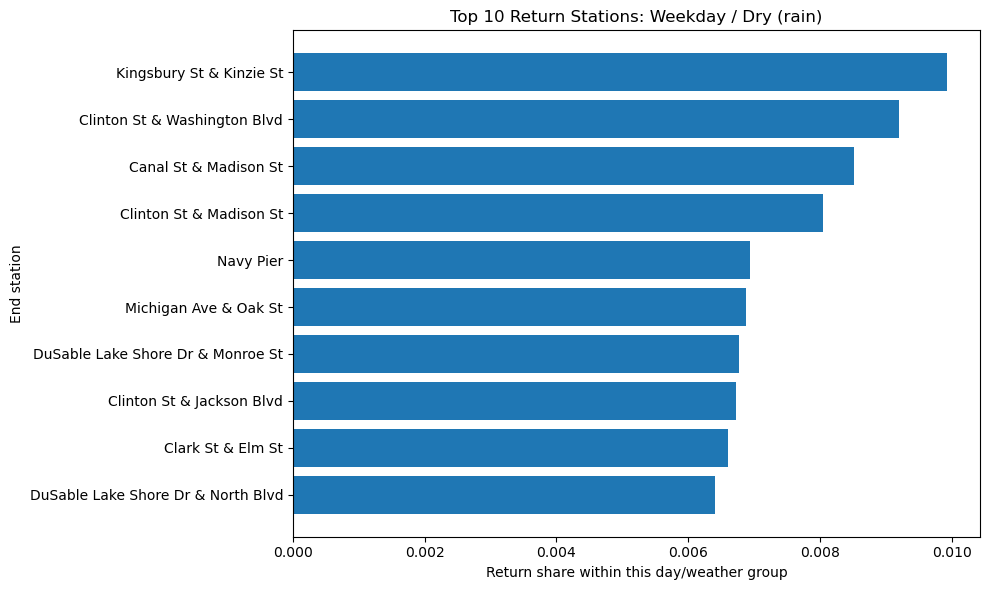

Saved: outputs\weather_station_figures\top10_weekday_rain_dry_return_stations.png


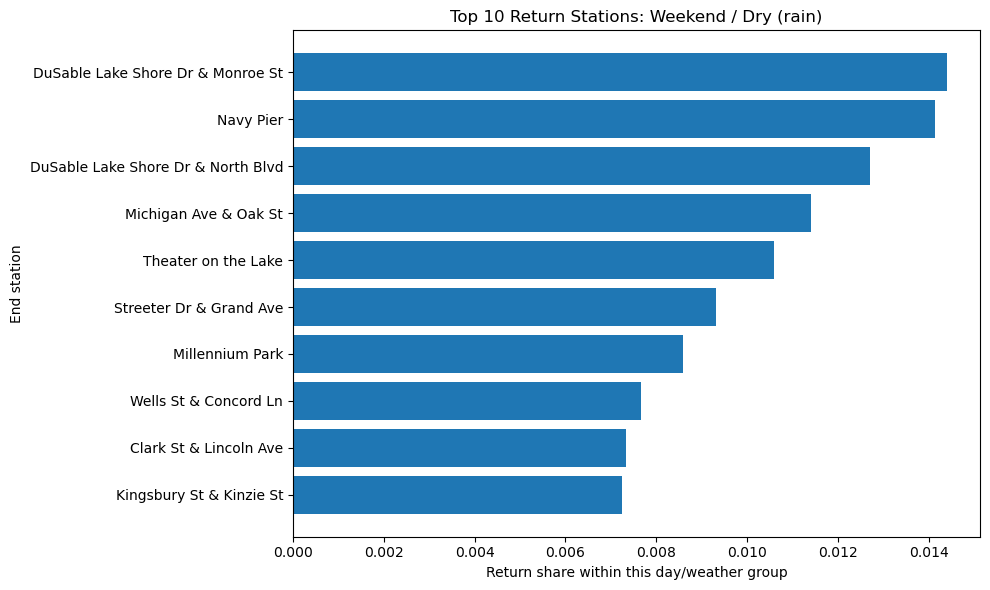

Saved: outputs\weather_station_figures\top10_weekend_rain_dry_return_stations.png


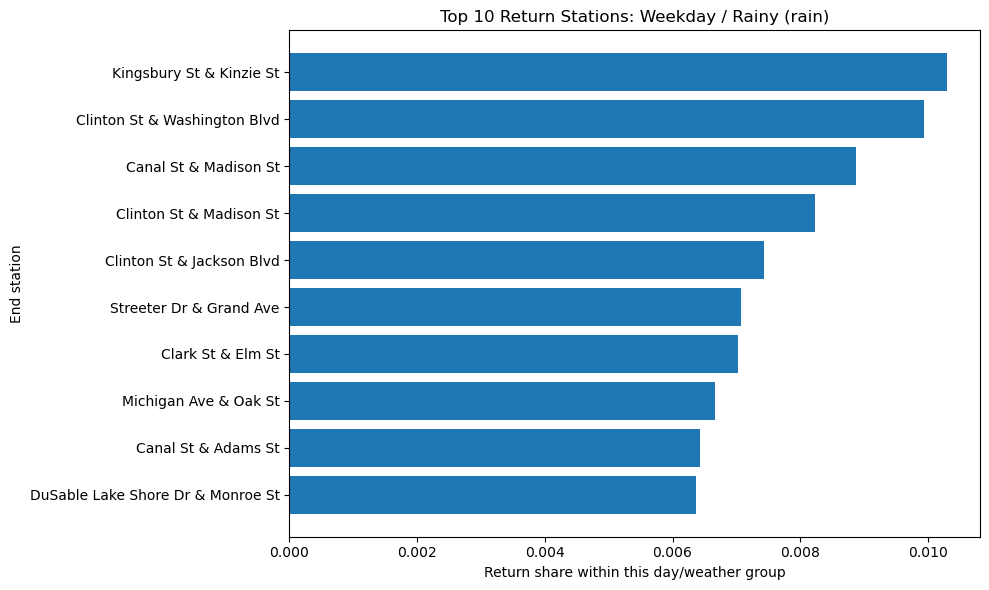

Saved: outputs\weather_station_figures\top10_weekday_rain_rainy_return_stations.png


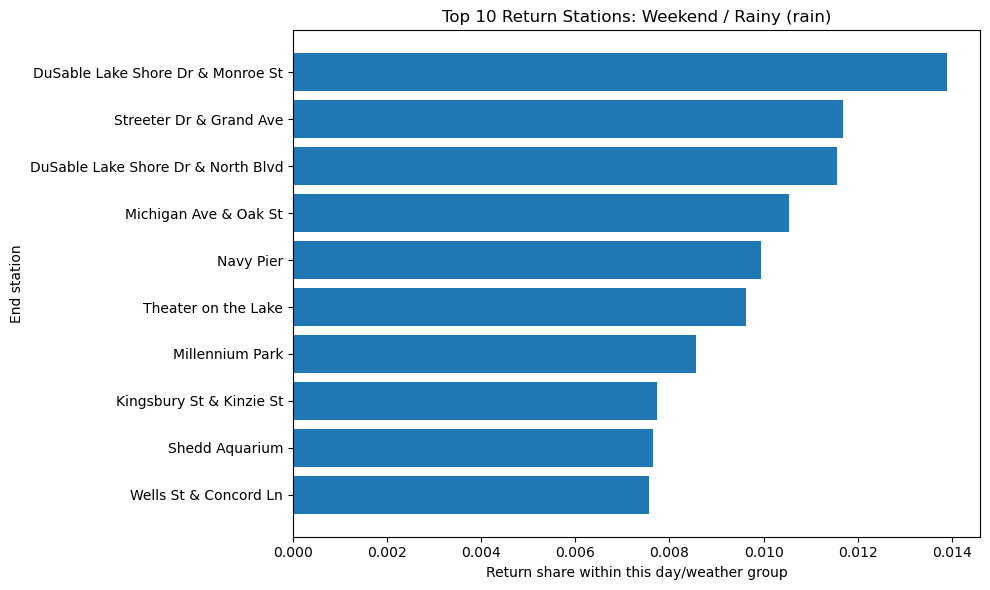

Saved: outputs\weather_station_figures\top10_weekend_rain_rainy_return_stations.png


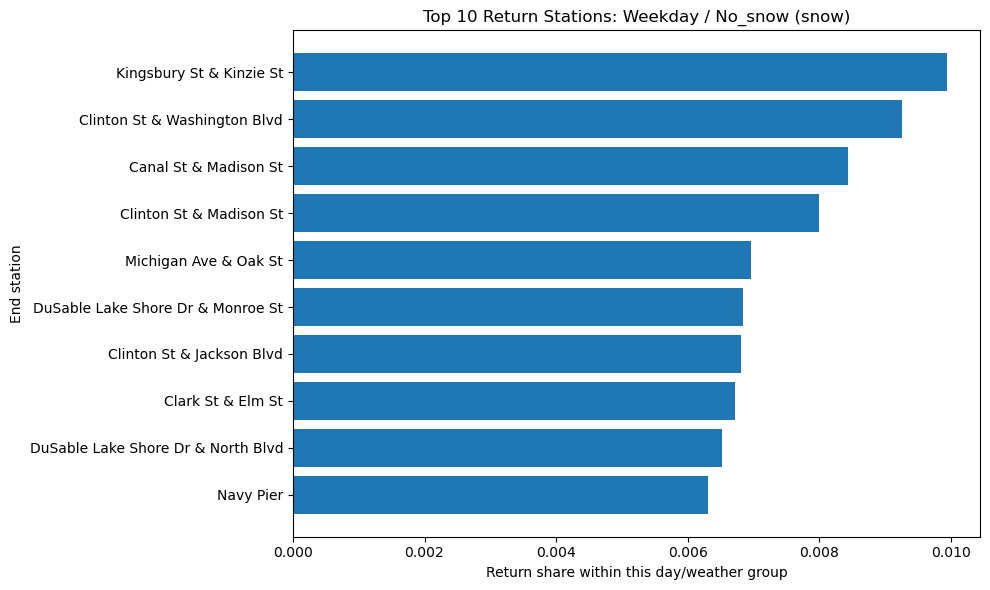

Saved: outputs\weather_station_figures\top10_weekday_snow_no_snow_return_stations.png


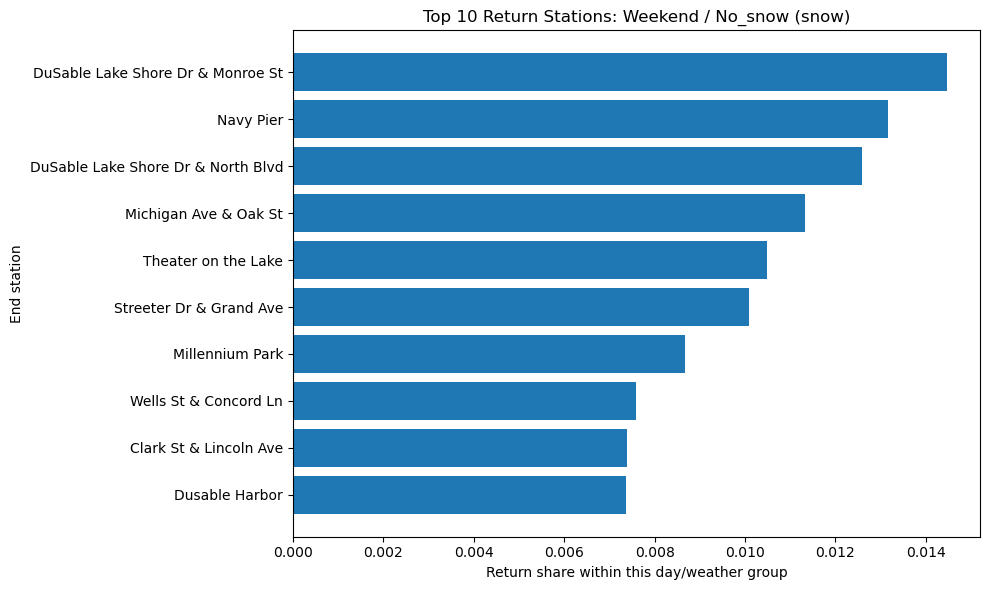

Saved: outputs\weather_station_figures\top10_weekend_snow_no_snow_return_stations.png


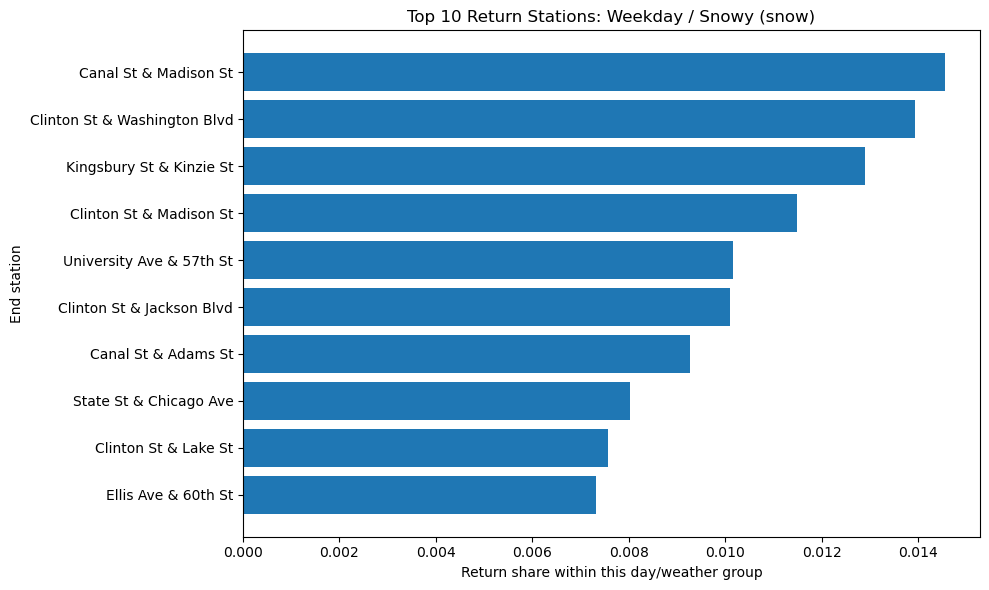

Saved: outputs\weather_station_figures\top10_weekday_snow_snowy_return_stations.png


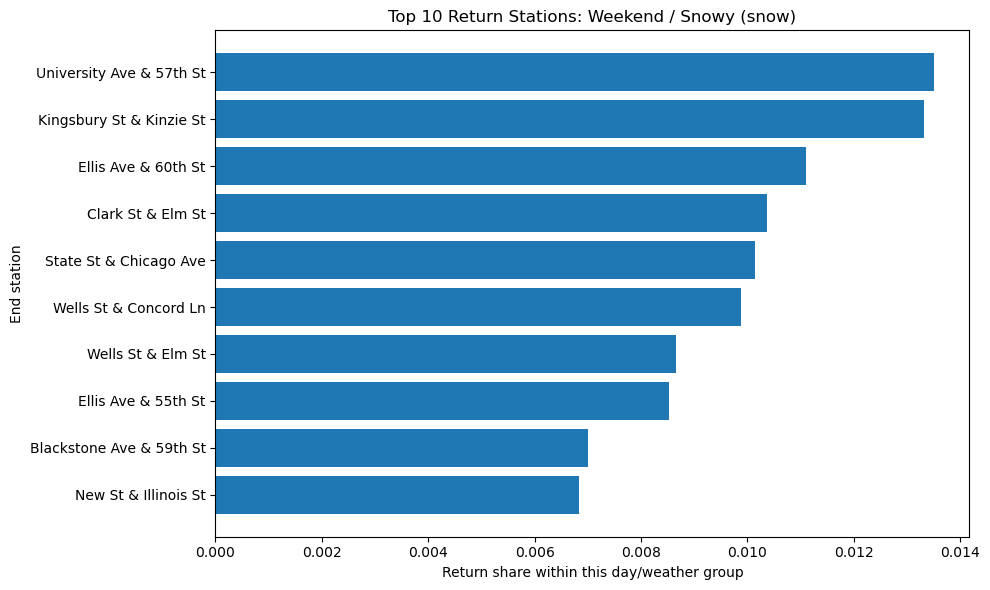

Saved: outputs\weather_station_figures\top10_weekend_snow_snowy_return_stations.png


In [3]:
FIG_DIR = os.path.join(OUTPUT_DIR, "weather_station_figures")
os.makedirs(FIG_DIR, exist_ok=True)

for (condition_type, condition_value, day_type), group in station_weather_geo.groupby(
    ["condition_type", "condition_value", "day_type"]
):
    top10 = (
        group
        .sort_values("return_share", ascending=False)
        .head(10)
        .copy()
    )
    
    if len(top10) == 0:
        continue
    
    plt.figure(figsize=(10, 6))
    plt.barh(
        top10["end_station_name"],
        top10["return_share"]
    )
    
    plt.xlabel("Return share within this day/weather group")
    plt.ylabel("End station")
    plt.title(
        f"Top 10 Return Stations: {day_type.capitalize()} / {condition_value.capitalize()} "
        f"({condition_type})"
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    safe_name = f"top10_{day_type}_{condition_type}_{condition_value}_return_stations.png"
    output_fig = os.path.join(FIG_DIR, safe_name)
    
    plt.savefig(output_fig, dpi=300)
    plt.show()
    
    print("Saved:", output_fig)

In [4]:
# Base map center
center_lat = station_weather_geo["end_lat"].mean()
center_lng = station_weather_geo["end_lng"].mean()

m_weather_heat = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12,
    tiles="OpenStreetMap"
)

# Add one heatmap layer for each day_type + weather condition
for (condition_type, condition_value, day_type), group in station_weather_geo.groupby(
    ["condition_type", "condition_value", "day_type"]
):
    layer_name = f"Heatmap: {day_type} | {condition_value} ({condition_type})"
    
    heat_layer = folium.FeatureGroup(
        name=layer_name,
        show=False
    )
    
    # Use return_count as heatmap weight
    heat_data = group[
        ["end_lat", "end_lng", "return_count"]
    ].dropna().values.tolist()
    
    if len(heat_data) == 0:
        continue
    
    HeatMap(
        heat_data,
        radius=18,
        blur=15,
        max_zoom=13
    ).add_to(heat_layer)
    
    heat_layer.add_to(m_weather_heat)

folium.LayerControl(collapsed=False).add_to(m_weather_heat)

output_map = os.path.join(
    OUTPUT_DIR,
    "weather_daytype_end_station_heatmaps.html"
)

m_weather_heat.save(output_map)

print("Saved:", output_map)
m_weather_heat

Saved: outputs\weather_daytype_end_station_heatmaps.html


In [5]:
weather_daytype_diff_rows = []

for (condition_type, condition_value), group in station_weather_geo.groupby(
    ["condition_type", "condition_value"]
):
    temp = group.pivot_table(
        index="end_station_name",
        columns="day_type",
        values=["return_count", "return_share"],
        fill_value=0
    ).reset_index()
    
    temp.columns = [
        "_".join([str(x) for x in col if x != ""])
        for col in temp.columns
    ]
    
    for col in [
        "return_count_weekday",
        "return_count_weekend",
        "return_share_weekday",
        "return_share_weekend"
    ]:
        if col not in temp.columns:
            temp[col] = 0
    
    temp["condition_type"] = condition_type
    temp["condition_value"] = condition_value
    
    temp["weekend_minus_weekday_share_under_weather"] = (
        temp["return_share_weekend"] -
        temp["return_share_weekday"]
    )
    
    temp["total_return_count_under_weather"] = (
        temp["return_count_weekday"] +
        temp["return_count_weekend"]
    )
    
    temp = temp.merge(
        station_coords,
        on="end_station_name",
        how="left"
    )
    
    weather_daytype_diff_rows.append(temp)

weather_daytype_diff = pd.concat(weather_daytype_diff_rows, ignore_index=True)

# Filter small stations
weather_daytype_diff = weather_daytype_diff[
    weather_daytype_diff["total_return_count_under_weather"] >= 50
].copy()

output_csv = os.path.join(
    OUTPUT_DIR,
    "weather_specific_weekend_minus_weekday_station_difference.csv"
)

weather_daytype_diff.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(weather_daytype_diff.head())

Saved: outputs\weather_specific_weekend_minus_weekday_station_difference.csv


,end_station_name,return_count_weekday,return_count_weekend,return_share_weekday,return_share_weekend,condition_type,condition_value,weekend_minus_weekday_share_under_weather,total_return_count_under_weather,end_lat,end_lng
0,2112 W Peterson Ave,41.0,33.0,0.000143,0.000409,cold,cold,0.000265,74.0,41.991178,-87.683593
3,900 W Harrison St,862.0,156.0,0.003014,0.001932,cold,cold,-0.001082,1018.0,41.874754,-87.649807
5,Aberdeen St & Carroll Ave,275.0,58.0,0.000962,0.000718,cold,cold,-0.000243,333.0,41.888190,-87.654590
6,Aberdeen St & Jackson Blvd,1085.0,337.0,0.003794,0.004174,cold,cold,0.000380,1422.0,41.877726,-87.654787
7,Aberdeen St & Monroe St,687.0,136.0,0.002402,0.001685,cold,cold,-0.000718,823.0,41.880382,-87.655409


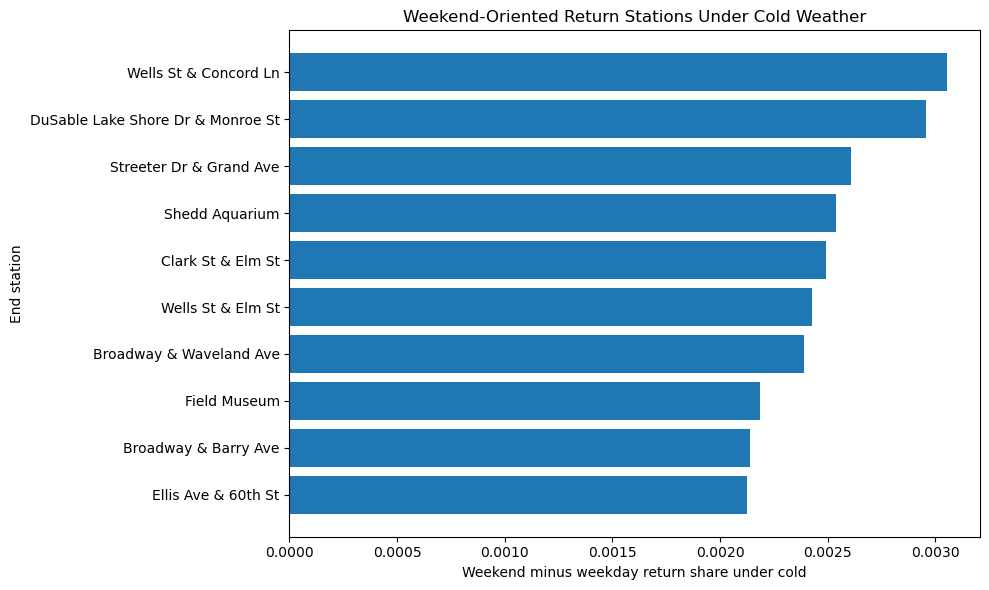

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_cold_cold.png


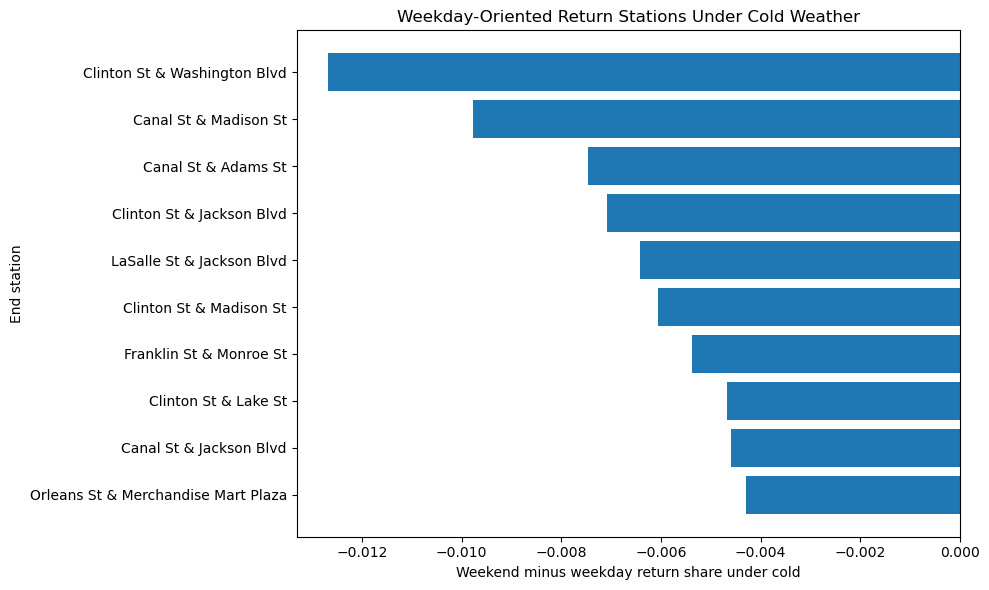

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_cold_cold.png


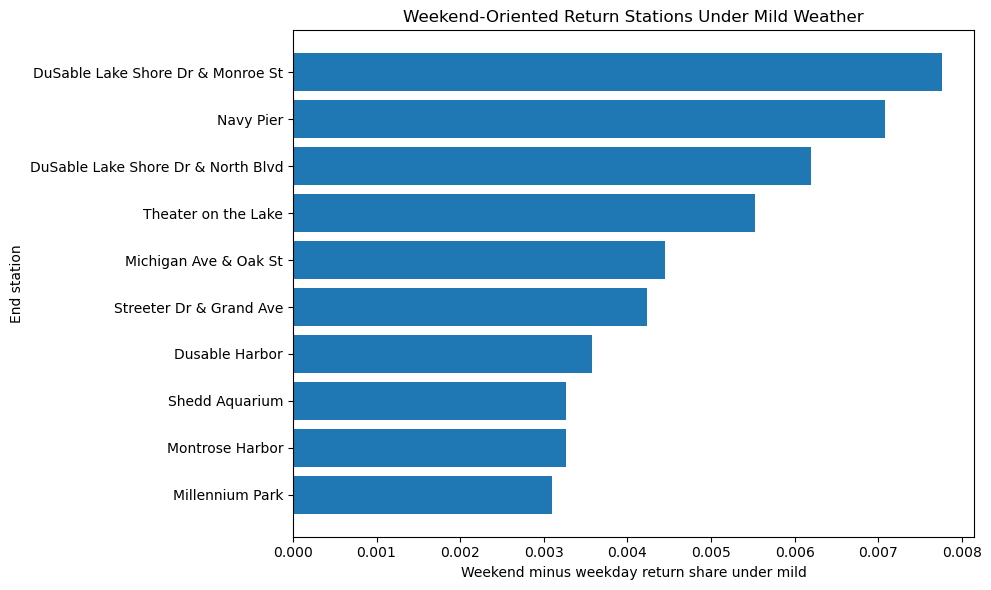

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_cold_mild.png


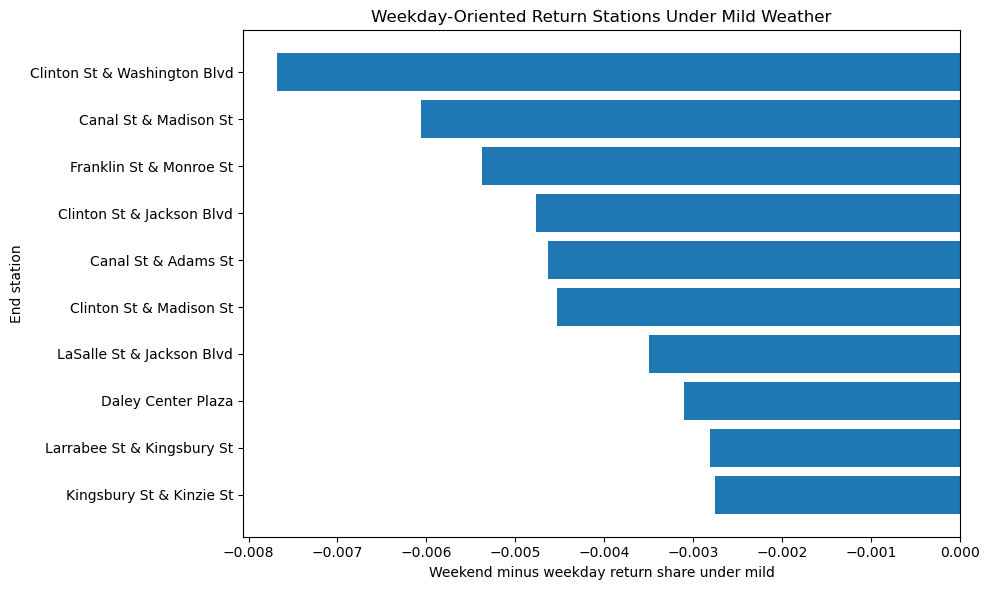

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_cold_mild.png


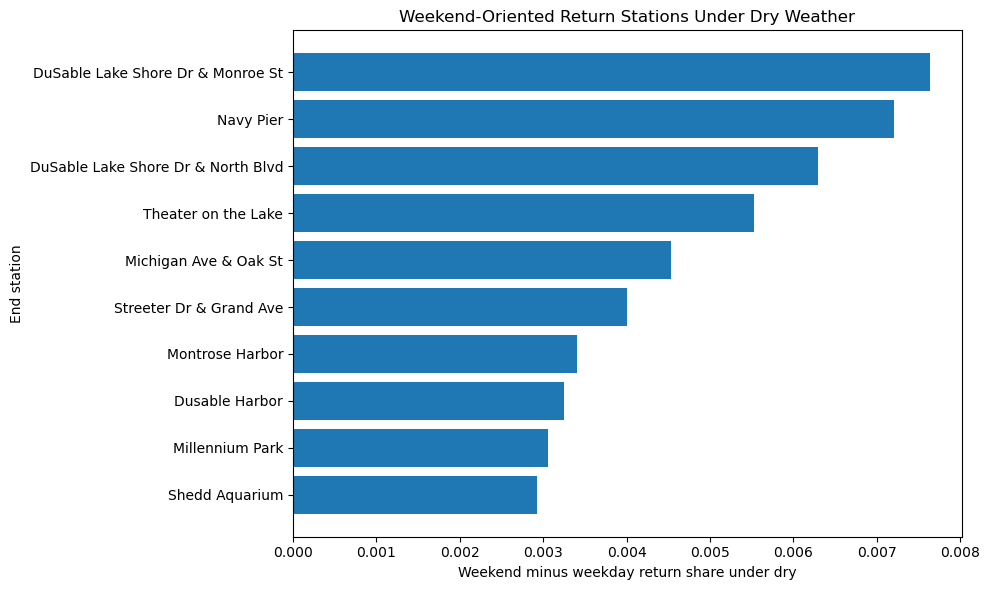

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_rain_dry.png


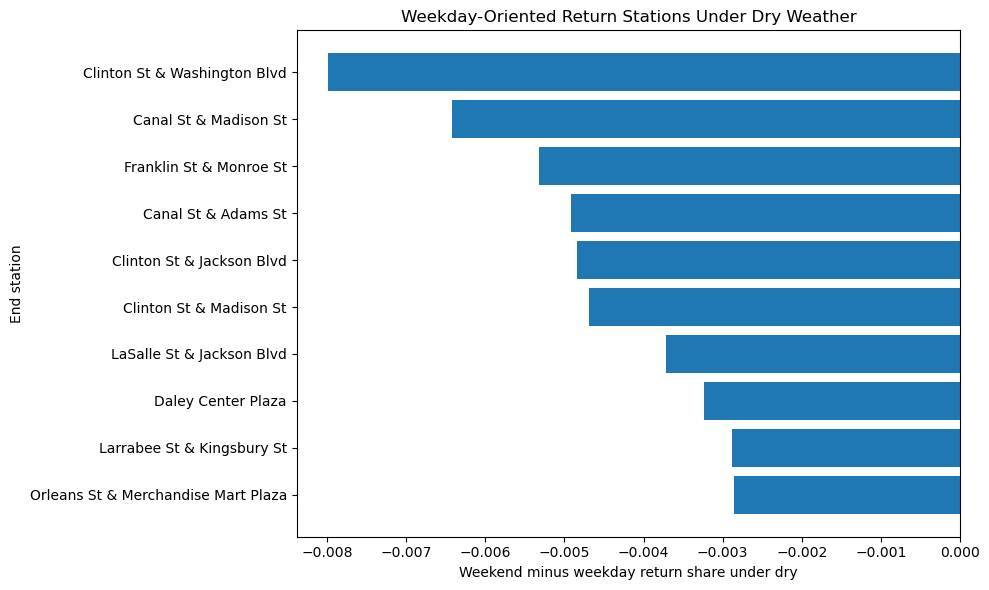

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_rain_dry.png


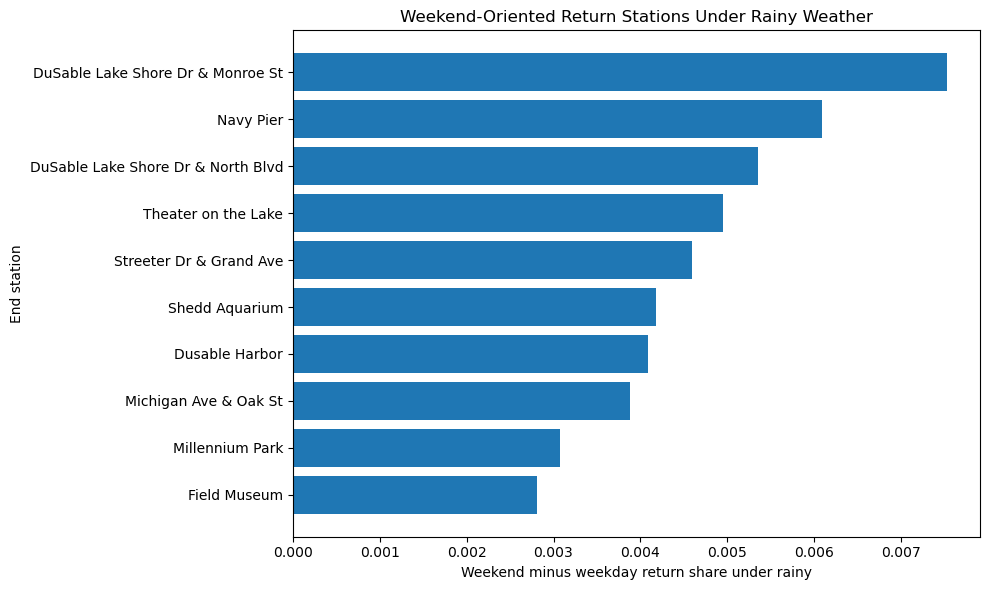

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_rain_rainy.png


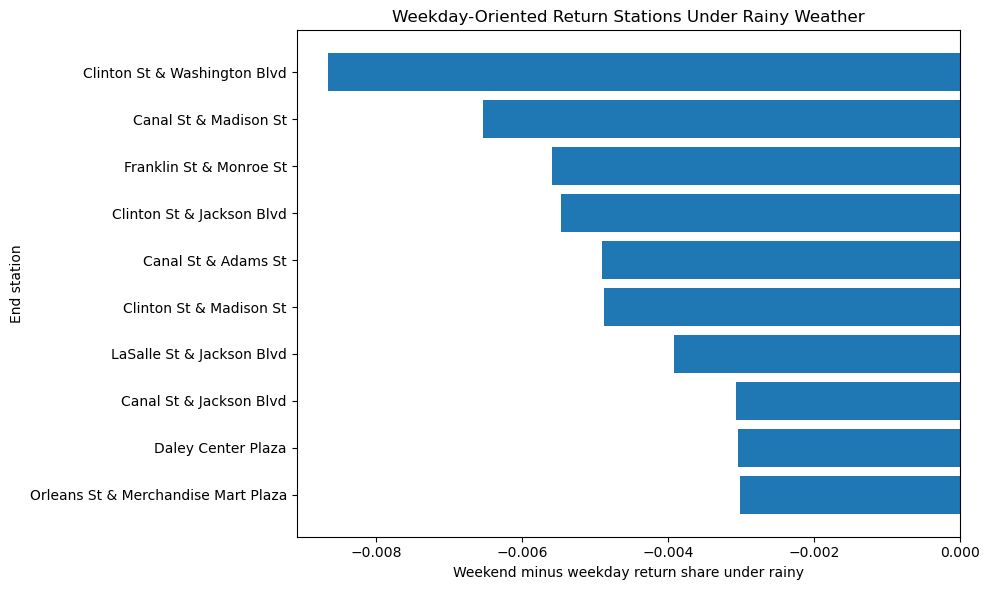

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_rain_rainy.png


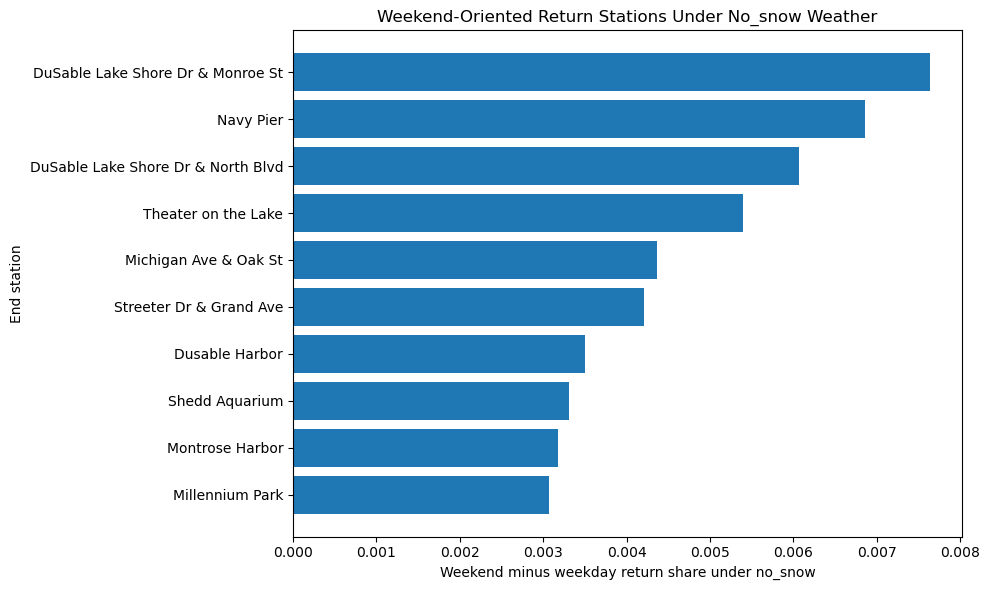

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_snow_no_snow.png


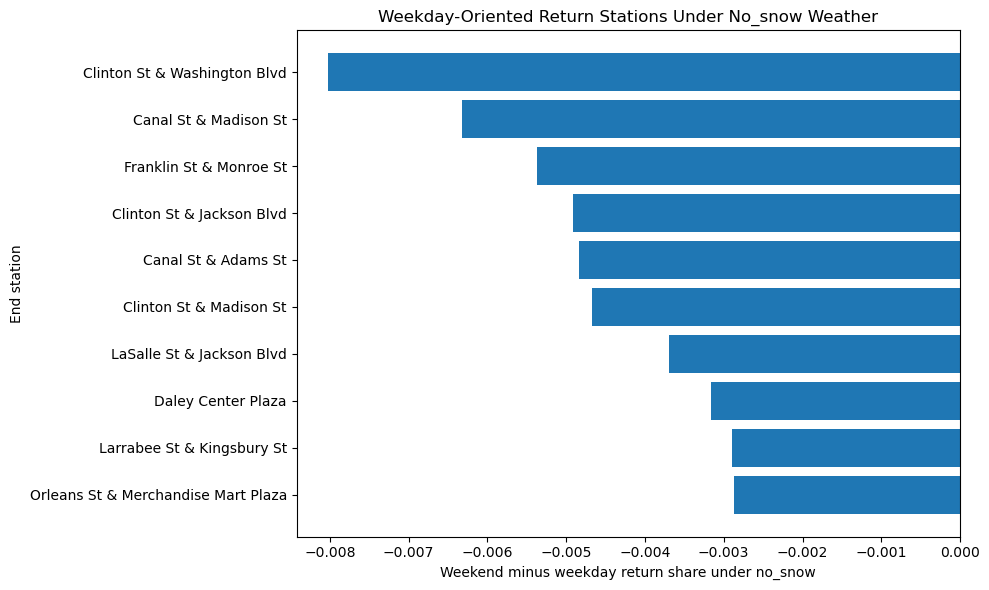

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_snow_no_snow.png


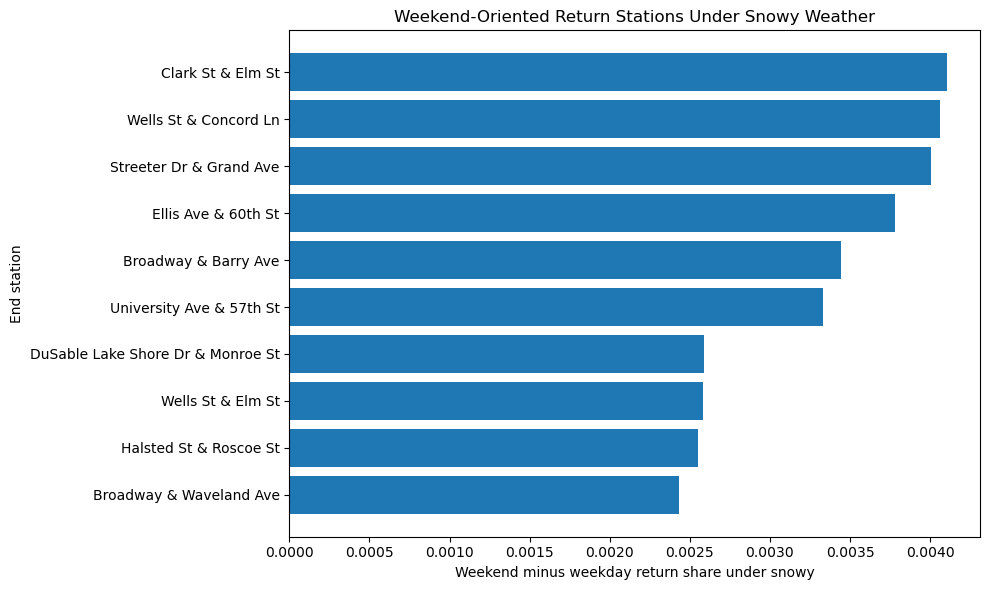

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekend_oriented_under_snow_snowy.png


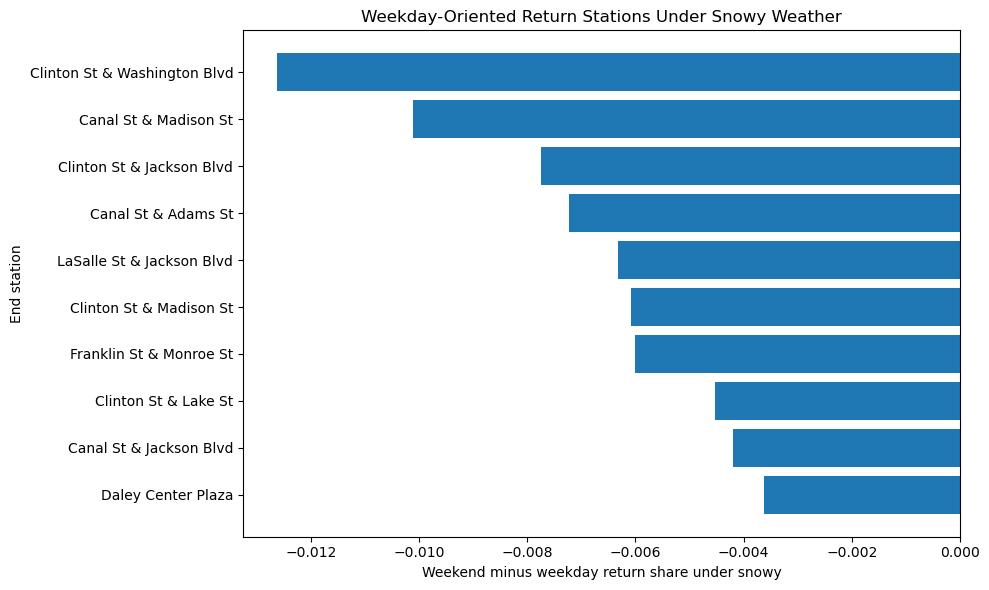

Saved: outputs\weather_weekday_weekend_difference_figures\top10_weekday_oriented_under_snow_snowy.png


In [6]:
DIFF_FIG_DIR = os.path.join(OUTPUT_DIR, "weather_weekday_weekend_difference_figures")
os.makedirs(DIFF_FIG_DIR, exist_ok=True)

for (condition_type, condition_value), group in weather_daytype_diff.groupby(
    ["condition_type", "condition_value"]
):
    # Top weekend-oriented under this weather
    top_weekend = (
        group
        .sort_values("weekend_minus_weekday_share_under_weather", ascending=False)
        .head(10)
        .copy()
    )
    
    plt.figure(figsize=(10, 6))
    plt.barh(
        top_weekend["end_station_name"],
        top_weekend["weekend_minus_weekday_share_under_weather"]
    )
    plt.xlabel(f"Weekend minus weekday return share under {condition_value}")
    plt.ylabel("End station")
    plt.title(f"Weekend-Oriented Return Stations Under {condition_value.capitalize()} Weather")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    output_fig = os.path.join(
        DIFF_FIG_DIR,
        f"top10_weekend_oriented_under_{condition_type}_{condition_value}.png"
    )
    
    plt.savefig(output_fig, dpi=300)
    plt.show()
    print("Saved:", output_fig)
    
    
    # Top weekday-oriented under this weather
    top_weekday = (
        group
        .sort_values("weekend_minus_weekday_share_under_weather", ascending=True)
        .head(10)
        .copy()
    )
    
    plt.figure(figsize=(10, 6))
    plt.barh(
        top_weekday["end_station_name"],
        top_weekday["weekend_minus_weekday_share_under_weather"]
    )
    plt.xlabel(f"Weekend minus weekday return share under {condition_value}")
    plt.ylabel("End station")
    plt.title(f"Weekday-Oriented Return Stations Under {condition_value.capitalize()} Weather")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    output_fig = os.path.join(
        DIFF_FIG_DIR,
        f"top10_weekday_oriented_under_{condition_type}_{condition_value}.png"
    )
    
    plt.savefig(output_fig, dpi=300)
    plt.show()
    print("Saved:", output_fig)

In [7]:
m_weather_diff = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12,
    tiles="OpenStreetMap"
)

for (condition_type, condition_value), group in weather_daytype_diff.groupby(
    ["condition_type", "condition_value"]
):
    top_weekend = (
        group
        .sort_values("weekend_minus_weekday_share_under_weather", ascending=False)
        .head(20)
        .copy()
    )
    
    top_weekday = (
        group
        .sort_values("weekend_minus_weekday_share_under_weather", ascending=True)
        .head(20)
        .copy()
    )
    
    weekend_layer = folium.FeatureGroup(
        name=f"Weekend-oriented under {condition_value} ({condition_type})",
        show=False
    )
    
    weekday_layer = folium.FeatureGroup(
        name=f"Weekday-oriented under {condition_value} ({condition_type})",
        show=False
    )
    
    for _, row in top_weekend.iterrows():
        popup_html = f"""
        <div style="width: 340px;">
            <h4>{row['end_station_name']}</h4>
            <b>Weather condition:</b> {condition_value} ({condition_type})<br>
            <b>Weekday returns:</b> {int(row['return_count_weekday'])}<br>
            <b>Weekend returns:</b> {int(row['return_count_weekend'])}<br>
            <b>Weekday share:</b> {row['return_share_weekday']:.6f}<br>
            <b>Weekend share:</b> {row['return_share_weekend']:.6f}<br>
            <b>Weekend - weekday share:</b> {row['weekend_minus_weekday_share_under_weather']:.6f}<br>
            <br>
            <i>Positive value means this station is relatively more weekend-oriented under this weather condition.</i>
        </div>
        """
        
        radius = 6 + np.log1p(abs(row["weekend_minus_weekday_share_under_weather"]) * 1_000_000)
        
        folium.CircleMarker(
            location=[row["end_lat"], row["end_lng"]],
            radius=radius,
            popup=folium.Popup(popup_html, max_width=370),
            tooltip=f"Weekend-oriented under {condition_value}: {row['end_station_name']}",
            fill=True,
            fill_opacity=0.75
        ).add_to(weekend_layer)
    
    for _, row in top_weekday.iterrows():
        popup_html = f"""
        <div style="width: 340px;">
            <h4>{row['end_station_name']}</h4>
            <b>Weather condition:</b> {condition_value} ({condition_type})<br>
            <b>Weekday returns:</b> {int(row['return_count_weekday'])}<br>
            <b>Weekend returns:</b> {int(row['return_count_weekend'])}<br>
            <b>Weekday share:</b> {row['return_share_weekday']:.6f}<br>
            <b>Weekend share:</b> {row['return_share_weekend']:.6f}<br>
            <b>Weekend - weekday share:</b> {row['weekend_minus_weekday_share_under_weather']:.6f}<br>
            <br>
            <i>Negative value means this station is relatively more weekday-oriented under this weather condition.</i>
        </div>
        """
        
        radius = 6 + np.log1p(abs(row["weekend_minus_weekday_share_under_weather"]) * 1_000_000)
        
        folium.CircleMarker(
            location=[row["end_lat"], row["end_lng"]],
            radius=radius,
            popup=folium.Popup(popup_html, max_width=370),
            tooltip=f"Weekday-oriented under {condition_value}: {row['end_station_name']}",
            fill=True,
            fill_opacity=0.75
        ).add_to(weekday_layer)
    
    weekend_layer.add_to(m_weather_diff)
    weekday_layer.add_to(m_weather_diff)

folium.LayerControl(collapsed=False).add_to(m_weather_diff)

output_map = os.path.join(
    OUTPUT_DIR,
    "weather_specific_weekday_weekend_difference_station_map.html"
)

m_weather_diff.save(output_map)

print("Saved:", output_map)
m_weather_diff

Saved: outputs\weather_specific_weekday_weekend_difference_station_map.html
